# 🚲 Bike Sharing Demand: Time-Series Regression & MLOps Pipeline

---

## 📌 1. Project Overview
This project focuses on building an end-to-end Machine Learning regression pipeline to accurately predict hourly urban **bike-sharing demand** (`cnt`). By capturing environmental, meteorological, seasonal, and temporal patterns, this pipeline automates feature engineering, evaluates multiple regression algorithms, handles multicollinearity, tracks experiments using **MLflow**, and deploys an interactive prediction interface via **Gradio**.

---

## 📊 2. About the Dataset
The dataset originates from the **Capital / Seoul Bike Sharing** records, capturing environmental conditions and hourly rental logs:

* **Target Variable:** `cnt` (Total Rented Bike Count per hour — Continuous)
* **Temporal Attributes:** `season`, `yr`, `mnth`, `hr`, `holiday`, `weekday`, `workingday`
* **Meteorological Attributes:** `weathersit` (Weather Condition), `temp` (Normalized Temperature), `atemp` (Normalized Feeling Temperature), `hum` (Normalized Humidity), `windspeed` (Normalized Windspeed)

---

## 🎯 3. Core Problem & How I Solved It
* **The Core Challenge:** Hourly rental demand exhibits strong non-linear interactions driven by rush hours, weather shifts, and severe multicollinearity between `temp` and `atemp` ($r \approx 0.99$). Raw features limit regression models from capturing daily peak trends and cyclical temporal dynamics.
* **The Solution:** 
  1. **Multicollinearity Optimization:** Analyzed inter-variable correlations and prioritized `temp` over `atemp` to streamline model stability and eliminate feature redundancy.
  2. **Domain-Driven Feature Engineering:** Crafted peak-hour indicators, cyclical time encodings ($\sin/\cos$ transformations for hour and month), and weather interaction terms via a custom `BikeFeatureEngineer` pipeline step.
  3. **Robust Preprocessing & Outlier Handling:** Integrated an IQR-based `OutlierHandler`, `RobustScaler`, and `OneHotEncoder` inside a scikit-learn `ColumnTransformer`.
  4. **MLOps & Evaluation Strategy:** Utilized `RandomizedSearchCV` for hyperparameter optimization across multiple algorithms, tracked all runs in **MLflow**, evaluated on a dedicated validation set (`X_val_processed`), and packaged the final model alongside a **Model Card**, deployment artifacts, and a **Gradio UI**.

---

## 🗺️ 4. Project Roadmap
1. **Data Ingestion & Hygiene:** Load historical hourly dataset, handle data types, and inspect missing values.
2. **Exploratory Data Analysis (EDA):** Analyze target distribution, hourly demand trends, and collinearity matrices (`temp` vs. `atemp`).
3. **Baseline Performance Setup:** Train and evaluate a raw-feature model (dropping `atemp`) to establish an empirical benchmark ($R^2$, RMSE, MAE).
4. **Feature Alchemy & Pipeline Construction:** Implement custom transformers for cyclical time features, peak hours, robust scaling, and outlier capping.
5. **Model Optimization & MLOps Tracking:** Perform hyperparameter searches (`RandomizedSearchCV`), log experiments, metrics, and models to **MLflow**.
6. **Package Deployment & Model Card:** Version and persist `best_model.pkl`, `preprocessor.pkl`, and generate a structured `model_card.json`.
7. **Interactive UI Deployment:** Launch a user-friendly **Gradio** web application for real-time demand inference with built-in input validation.

---

## 🛠️ 5. Production Environment Setup

### 🛠️ Core Python Libraries
* **NumPy:** High-performance vector operations and mathematical transformations.
* **Pandas:** Structured data manipulation, cleaning, and time-series feature crafting.
* **Matplotlib & Seaborn:** Visualizing correlation heatmaps, feature distributions, and actual vs. predicted demand.
* **SciPy:** Statistical distributions and IQR outlier calculations.
* **Joblib:** Serializing trained model pipelines and preprocessor artifacts.
* **JSON & OS:** Versioning directory creation, configuration management, and model card generation.

### 🧰 Scikit-Learn & MLOps Toolset
* **Preprocessing & Feature Transformers:** `ColumnTransformer`, `RobustScaler`, `OneHotEncoder`, `BaseEstimator`, `TransformerMixin`.
* **Model Selection & Tuning:** `train_test_split`, `RandomizedSearchCV`, `KFold`.
* **Regression Algorithms:** `LinearRegression`, `Ridge`, `Lasso`, `RandomForestRegressor`, `GradientBoostingRegressor`.
* **Evaluation Metrics:** Mean Squared Error (RMSE), Mean Absolute Error (MAE), Coefficient of Determination ($R^2$).
* **MLOps Tracking & UI:** `MLflow` for experiment tracking and metric logging; `Gradio` for real-time model inference.

In [59]:
# 🛠️ Advanced imports for production ML

# Suppress warnings for cleaner outputs
import warnings
warnings.filterwarnings('ignore')

# 🔧 Core Python libraries
import numpy as np           # Efficient numerical computations
import pandas as pd          # Data manipulation and analysis
import matplotlib.pyplot as plt  # Basic plotting
import seaborn as sns        # Advanced visualization
from scipy import stats      # Statistical functions
import joblib               # Save/load large models and preprocessing objects
import json                 # Handle JSON configs and outputs
from datetime import datetime  # Timestamping for logs
import os                   # File system operations
import time                 # Time tracking for experiments

# 🧰 Sklearn libraries - expanded for advanced ML workflows
from sklearn.datasets import fetch_california_housing  # Real-world dataset
from sklearn.model_selection import (
    train_test_split,     # Split data into train/test sets
    cross_val_score,      # Cross-validation scoring
    GridSearchCV,         # Hyperparameter tuning (grid search)
    RandomizedSearchCV    # Hyperparameter tuning (randomized search)
)
from sklearn.preprocessing import (
    StandardScaler,       # Feature scaling (zero-mean, unit variance)
    RobustScaler,         # Scaling robust to outliers
    PolynomialFeatures    # Generate polynomial features for non-linear relationships
)
from sklearn.pipeline import Pipeline, FeatureUnion  # Build modular pipelines
from sklearn.compose import ColumnTransformer         # Apply different preprocessing to columns
from sklearn.feature_selection import (
    SelectKBest,          # Univariate feature selection
    f_regression,         # Scoring function for regression
    RFE                   # Recursive feature elimination
)
from sklearn.linear_model import (
    LinearRegression,     # Baseline regression
    Ridge,                # L2-regularized regression
    Lasso,                # L1-regularized regression
    ElasticNet            # Combination of L1 and L2 regularization
)
from sklearn.ensemble import (
    RandomForestRegressor,       # Ensemble of decision trees
    GradientBoostingRegressor,   # Boosted trees for regression
    VotingRegressor              # Combine multiple regressors
)
from sklearn.svm import SVR               # Support Vector Regression
from sklearn.metrics import (
    mean_squared_error,  # Regression metric
    r2_score,            # Regression metric
    mean_absolute_error  # Regression metric
)
from sklearn.inspection import (
    permutation_importance,       # Feature importance
    PartialDependenceDisplay      # Partial dependence plots
)

# 🧪 Advanced model tracking with MLflow
import mlflow                  # Experiment tracking
import mlflow.sklearn          # Log sklearn models
from mlflow.models.signature import infer_signature  # Auto-capture input/output schema for reproducible deployment


# 🎛️ Configuration & Reproducibility

Before we start modeling, it’s crucial to **establish reproducible and scalable experiment settings**. This ensures that results are consistent, experiments are traceable, and your workflow is production-ready.

### Key Components:

1. **Reproducibility**
   - `RANDOM_STATE = 42`: Ensures that every run produces the same train/test splits, random sampling, and model results.
   - `TEST_SIZE = 0.2`: Reserves 20% of the data for final evaluation.
   - `VAL_SIZE = 0.2`: Reserves a portion of the training data for validation and hyperparameter tuning.
   - `CV_FOLDS = 5`: Use 5-fold cross-validation to evaluate models robustly.
   - `N_JOBS = -1`: Utilizes all available CPU cores to speed up computations.

2. **Organized Project Structure**
   - `MODEL_DIR = "models"`: All trained models are stored in a dedicated folder.
   - `EXPERIMENT_DIR = "experiments"`: All MLflow experiment logs, metrics, and artifacts are saved in a centralized location.
   - `os.makedirs(..., exist_ok=True)`: Ensures directories exist, preventing file errors during training or logging.

3. **MLflow Experiment Tracking**
   - `mlflow.set_tracking_uri(...)` points MLflow to the experiment folder.
   - `mlflow.set_experiment(experiment_name)` creates a named experiment for this project.
   - This allows you to **log models, metrics, and hyperparameters**, enabling easy comparison across experiments.

> 💡 **Pro Tip:** Proper configuration and tracking is like laying the foundation of a building—everything built on top will be reliable, reproducible, and easy to maintain.


In [60]:
from numpy.compat import Path


class Config:
    # Reproducibility - Critical for production!
    RANDOM_STATE = 42
    TEST_SIZE = 0.2
    VAL_SIZE = 0.2  # NEW: Validation set for tuning
    CV_FOLDS = 5
    N_JOBS = -1  # Use all available cores

    # Model directories - Organized project structure
    MODEL_DIR = "models"
    EXPERIMENT_DIR = "experiments"

    # Create directories if they don't exist
    os.makedirs(MODEL_DIR, exist_ok=True)
    os.makedirs(EXPERIMENT_DIR, exist_ok=True)

config = Config()

os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

# Initialize MLflow for experiment tracking
exp_uri = Path(config.EXPERIMENT_DIR).resolve().as_uri()
mlflow.set_tracking_uri(exp_uri)
experiment_name = "Bike Sharing Demand Prediction"
mlflow.set_experiment(experiment_name)


<Experiment: artifact_location='file:///C:/Users/Azza%20Omer/Desktop/SA_IR/SAIR_Jr/1_Regression/Regression%20Capstone%20Projects/Azza_Project/experiments/188649736873588123', creation_time=1790726213702, effective_trace_archival_retention=None, experiment_id='188649736873588123', last_update_time=1790726213702, lifecycle_stage='active', name='Bike Sharing Demand Prediction', tags={}, trace_location=None, workspace='default'>

### Model Development Lifecycle

```
Raw Data ➔ EDA ➔ Preprocessing ➔ Feature Engineering ➔ Model Training ➔ Evaluation ➔ Deployment

✅we will go with this lifecycle one by one , and will make perfect pipeline


## 🔍 Step 1: Loading the data


In [88]:


# Read files directly from the data folder
train_data = pd.read_csv("data/train.csv")
df_test = pd.read_csv("data/test.csv")


# Drop non-target leakage columns directly, ignore if not present
cols_to_remove = ['casual', 'registered']

df_train = train_data.drop(columns=cols_to_remove, errors='ignore')


print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

df_train.head(30)


Train shape: (10886, 10)
Test shape: (6493, 9)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,1
5,2011-01-01 05:00:00,1,0,0,2,9.84,12.880,75,6.0032,1
6,2011-01-01 06:00:00,1,0,0,1,9.02,13.635,80,0.0000,2
7,2011-01-01 07:00:00,1,0,0,1,8.20,12.880,86,0.0000,3
8,2011-01-01 08:00:00,1,0,0,1,9.84,14.395,75,0.0000,8
9,2011-01-01 09:00:00,1,0,0,1,13.12,17.425,76,0.0000,14


## 🔍 Step 2: Exploratory Data Analysis (EDA)

Before building models, we must **understand our data**:
- Check for missing values
- Understand distributions
- Detect outliers
- Explore relationships between features

In [62]:
# Basic statistics
print("=" * 70)
print("📊 DATASET STATISTICS")
print("=" * 70)
print(df_train.describe())


📊 DATASET STATISTICS
             season       holiday    workingday       weather         temp  \
count  10886.000000  10886.000000  10886.000000  10886.000000  10886.00000   
mean       2.506614      0.028569      0.680875      1.418427     20.23086   
std        1.116174      0.166599      0.466159      0.633839      7.79159   
min        1.000000      0.000000      0.000000      1.000000      0.82000   
25%        2.000000      0.000000      0.000000      1.000000     13.94000   
50%        3.000000      0.000000      1.000000      1.000000     20.50000   
75%        4.000000      0.000000      1.000000      2.000000     26.24000   
max        4.000000      1.000000      1.000000      4.000000     41.00000   

              atemp      humidity     windspeed         count  
count  10886.000000  10886.000000  10886.000000  10886.000000  
mean      23.655084     61.886460     12.799395    191.574132  
std        8.474601     19.245033      8.164537    181.144454  
min        0.760000 

## 🧹 Missing Values Check

If missing values were present, we could handle them using these common imputation strategies:

- **Mean** → Replace with the column’s average (for normal numeric data).
- **Median** → Replace with the middle value (robust to outliers).
- **Most Frequent (Mode)** → Replace with the most common value (for categorical data).

These techniques ensure data consistency and prevent model bias caused by incomplete records.

In [63]:
# Missing values check for training dataset
print("\n" + "=" * 70)
print("🔍 MISSING VALUES CHECK(TRAIN DATASET)")
print("=" * 70)
print(df_train.isnull().sum())



🔍 MISSING VALUES CHECK(TRAIN DATASET)
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
count         0
dtype: int64


In [64]:
# Missing values check for test dataset
print("\n" + "=" * 70)
print("🔍 MISSING VALUES CHECK (TEST DATASET)")
print("=" * 70)
print(df_test.isnull().sum())



🔍 MISSING VALUES CHECK (TEST DATASET)
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
dtype: int64


#### All datasets were inspected, and **no missing values** were found — great news! ✅  


#### Check Data types

In [65]:
# Data types for training dataset
print("\n" + "=" * 70)
print("📋 DATA TYPES")
print("=" * 70)
print(df_train.dtypes)



📋 DATA TYPES
datetime          str
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
count           int64
dtype: object


In [66]:
# Data types for test dataset
print("\n" + "=" * 70)
print("📋 DATA TYPES")
print("=" * 70)
print(df_test.dtypes)



📋 DATA TYPES
datetime          str
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
dtype: object


## 🧩 Data Type Verification & Casting

We verify feature data types and enforce proper type casting. The `datetime` column is initially stored as a `string/object` and needs to be explicitly converted into a standard `datetime64` format for temporal indexing and extraction.

In [67]:
# Convert datetime string column to datetime type
df_train['datetime'] = pd.to_datetime(df_train['datetime'])
df_test['datetime'] = pd.to_datetime(df_test['datetime'])

print("Data types after casting:")
print(df_train.dtypes[['datetime']])
print(df_test.dtypes[['datetime']])


Data types after casting:
datetime    datetime64[us]
dtype: object
datetime    datetime64[us]
dtype: object


### 🔮 Distribution & Outlier Analysis

In this section, we examine the underlying distributions of numerical features and detect potential outliers:
- **Histograms & KDE**(Kernel Density Estimate): Used to assess the skewness and normality of continuous variables, including the target feature (`count`).
- **Boxplots**: Used to identify extreme values and statistical outliers across continuous numerical features (`temp`, `atemp`, `hum`, and `windspeed`).

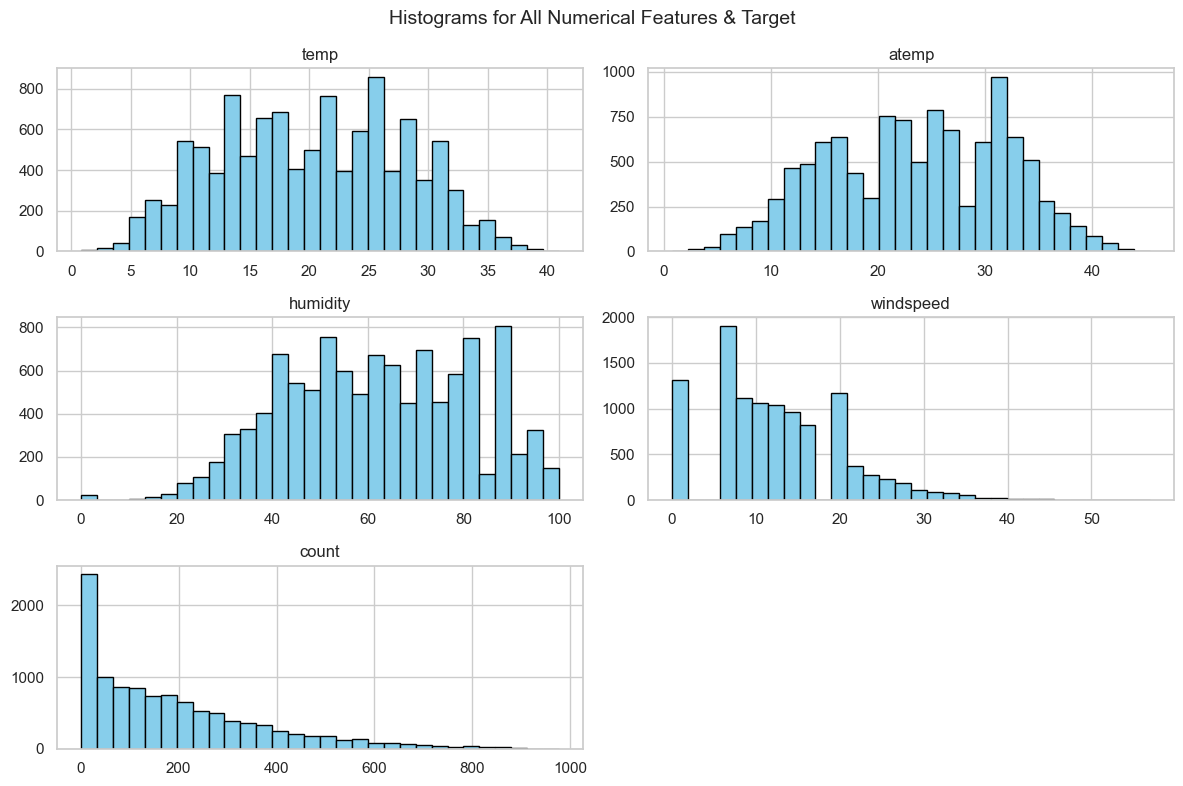

In [68]:
sns.set_theme(style="whitegrid")

# =========================================================
# 1. Histograms for All Numerical Features (Distribution Check)
# =========================================================
num_features = ['temp', 'atemp', 'humidity', 'windspeed', 'count']

df_train[num_features].hist(figsize=(12, 8), bins=30, color='skyblue', edgecolor='black')
plt.suptitle("Histograms for All Numerical Features & Target", fontsize=14)
plt.tight_layout()
plt.show()


#### 📊 Distribution Analysis Insights

- **`count` (Target Variable)**:
  - Highly **right-skewed** (positively skewed).
  - Most hours exhibit low rental counts (concentrated between 0 and 200), while high-demand hours are relatively rare.

- **`windspeed`**:
  - Displays a prominent spike at value **0**, indicating a large volume of zero readings (likely missing or unrecorded data). Beyond zero, the distribution is right-skewed.

- **`temp` & `atemp`**:
  - Almost **symmetric (nearly normal)** distribution, with temperatures evenly concentrated around the mean/center.

- **`humidity`**:
  - Nearly **uniform** distribution, with a slight drop near zero values.

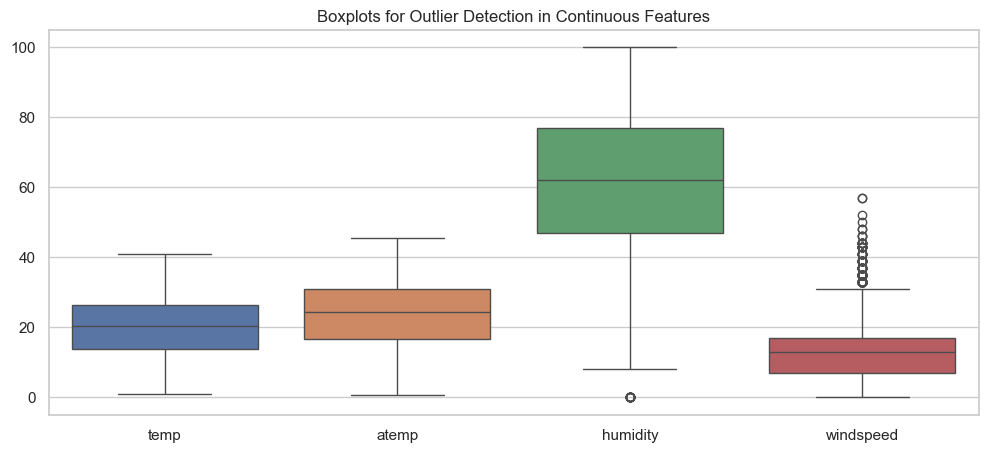

In [69]:
# 2. Boxplots for Continuous Features (Precise Outlier Check)
# =========================================================
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_train[['temp', 'atemp', 'humidity', 'windspeed']])
plt.title("Boxplots for Outlier Detection in Continuous Features")
plt.show()


#### 📌 Outlier Detection Summary (Boxplot Insights)

- **`temp` & `atemp`**: Show clean distributions with no detected outliers.
- **`humidity`**: Contains a few extreme low values (near 0).
- **`windspeed`**: Contains significant upper-bound outliers (values above ~31 mph/kph), represented by individual points above the upper whisker.

## 📊 Correlation Analysis

Understanding feature correlations helps us:
- Identify the most important features
- Detect multicollinearity
- Guide feature engineering

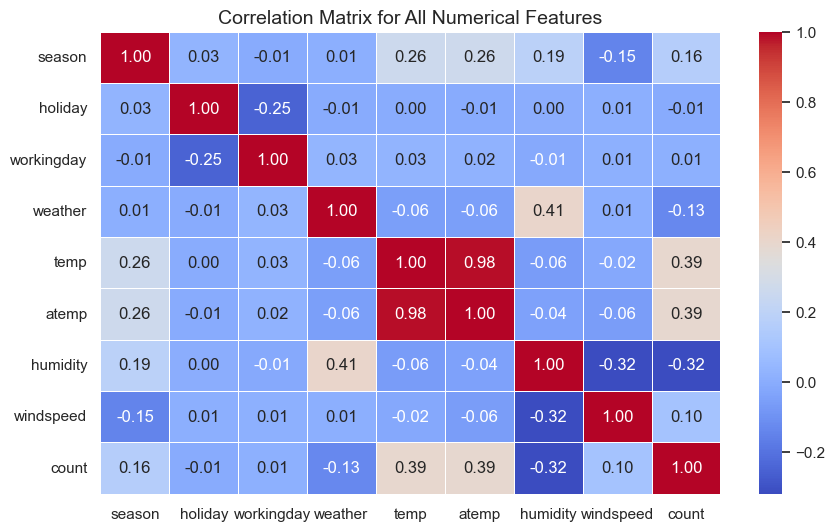

In [70]:
# =========================================================
# 3. Correlation Matrix Across All Numerical Features
# =========================================================
#plt.figure(figsize=(10, 6))
#correlation_matrix = df_train.select_dtypes(include=['number']).corr()
#sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
#plt.title("Correlation Matrix for All Features")
#plt.show()

plt.figure(figsize=(10, 6))
correlation_matrix = df_train.select_dtypes(include=['number']).corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix for All Numerical Features", fontsize=14)
plt.show()


#### 🔗 Correlation Analysis Insights

- **`temp` & `atemp` (Multicollinearity)**: 
  - Extremely strong positive correlation (**0.98**), indicating potential multicollinearity. One of these features could be dropped during feature selection to prevent redundancy.

- **Correlation with Target (`count`)**:
  - **`temp` & `atemp`**: Moderate positive correlation (**0.39**), showing that higher temperatures generally lead to higher bike rental demand.
  - **`humidity`**: Negative correlation (**-0.32**), indicating that higher humidity levels reduce rental demand.
  - **`season`**: Weak positive correlation (**0.16**).
  - **`weather`**: Weak negative correlation (**-0.13**).
  - **`windspeed`**: Very weak positive correlation (**0.10**).
  - **`holiday` & `workingday`**: Almost no linear correlation (**-0.01** and **0.01**), as their effect is better captured through temporal hour/day aggregations.

## if did not need all feature eng down delete it 

## 🛠️ Data Preprocessing & Advanced Feature Engineering

We design a custom `scikit-learn` compatible transformer `BikeFeatureEngineer` to systematically preprocess data anomalies and generate high-impact domain features:

### 1. Data Preprocessing
- **Temporal Extraction**: Convert `datetime` and extract structural time components (`hour`, `day`, `month`, `dayofweek`, and `year`), dropping the raw string column.
- **Windspeed Imputation**: Resolve zero-value data anomalies in `windspeed` by imputing them with conditional median values calculated across `season` and `weather` combinations (learned strictly from the training set).

### 2. Domain & Interaction Feature Engineering
- **`peak_hours`**: Binary indicator capturing commute rush-hour windows (7–9 AM and 5–7 PM).
- **`is_weekend`**: Binary flag identifying non-working weekend days (Saturday & Sunday).
- **`rush_hour_workingday`**: High-impact interaction feature (`peak_hours * workingday`) isolating workday commute spikes from weekend leisure traffic.
- **`is_night`**: Binary indicator for late-night/early-morning hours (23 PM–5 AM) where rental activity drops close to zero.
- **`temp_diff`**: Thermal comfort index derived from `atemp - temp` to capture the physical impact of humidity and wind force.

In [71]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class BikeFeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Custom Scikit-Learn Transformer for Bike Sharing Dataset.
    Handles Datetime feature extraction, windspeed zero-imputation,
    multicollinearity removal, and domain-specific feature engineering.
    """
    def __init__(self):
        self.windspeed_medians_ = {}
        self.global_wind_median_ = 0.0

    def fit(self, X, y=None):
        X_df = X.copy()

        # Calculate median windspeed grouped by season and weather (excluding zeros)
        valid_wind = X_df[X_df['windspeed'] > 0]
        self.windspeed_medians_ = valid_wind.groupby(['season', 'weather'])['windspeed'].median().to_dict()
        self.global_wind_median_ = valid_wind['windspeed'].median() if len(valid_wind) > 0 else 0.0
        return self

    def transform(self, X):
        X_df = X.copy()

        # 1. Convert datetime and extract temporal components
        if 'datetime' in X_df.columns:
            X_df['datetime'] = pd.to_datetime(X_df['datetime'])
            X_df['hour'] = X_df['datetime'].dt.hour
            X_df['day'] = X_df['datetime'].dt.day
            X_df['month'] = X_df['datetime'].dt.month
            X_df['dayofweek'] = X_df['datetime'].dt.dayofweek
            X_df['year'] = X_df['datetime'].dt.year
            X_df = X_df.drop(columns=['datetime'])

        # 2. Vectorized Imputation for Windspeed Zeros (Fast Performance)
        zero_mask = (X_df['windspeed'] == 0)
        if zero_mask.any():
            # Create group tuple lookup
            group_keys = list(zip(X_df.loc[zero_mask, 'season'], X_df.loc[zero_mask, 'weather']))
            imputed_values = [self.windspeed_medians_.get(k, self.global_wind_median_) for k in group_keys]
            X_df.loc[zero_mask, 'windspeed'] = imputed_values

        # 3. Handle Multicollinearity: Drop 'atemp' and keep 'temp'
        if 'atemp' in X_df.columns:
            X_df = X_df.drop(columns=['atemp'])

        # 4. Domain Feature Engineering
        # Commute Peak Hours: 7-9 AM (7, 8, 9) and 5-7 PM (17, 18, 19)
        X_df['peak_hours'] = X_df['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)
        X_df['is_weekend'] = X_df['dayofweek'].isin([5, 6]).astype(int)
        X_df['is_night'] = X_df['hour'].isin([23, 0, 1, 2, 3, 4, 5]).astype(int)

        # Interaction Feature: Rush hour on working days specifically
        if 'workingday' in X_df.columns:
            X_df['rush_hour_workingday'] = X_df['peak_hours'] * X_df['workingday']

        return X_df


# =========================================================
# Execution
# =========================================================
engineer = BikeFeatureEngineer()

# Fit & Transform Train Data
train_df_fe = engineer.fit_transform(df_train)

# Transform Test Data using medians learned from train (Prevents Data Leakage)
test_df_fe = engineer.transform(df_test)

print("🎯 FEATURE ENGINEERING COMPLETE!")
print(f"• Original train shape: {df_train.shape}")
print(f"• Processed train shape: {train_df_fe.shape}")
print("\nNew columns sample:")
print(train_df_fe[['hour', 'windspeed', 'peak_hours', 'is_weekend', 'rush_hour_workingday', 'is_night']].head())


🎯 FEATURE ENGINEERING COMPLETE!
• Original train shape: (10886, 10)
• Processed train shape: (10886, 17)

New columns sample:
   hour  windspeed  peak_hours  is_weekend  rush_hour_workingday  is_night
0     0    16.9979           0           1                     0         1
1     1    16.9979           0           1                     0         1
2     2    16.9979           0           1                     0         1
3     3    16.9979           0           1                     0         1
4     4    16.9979           0           1                     0         1


In [72]:
print(f"• Processed test shape: {test_df_fe.shape}")
print("\nTest set sample:")
test_df_fe[['hour', 'windspeed','peak_hours', 'is_weekend', 'rush_hour_workingday', 'is_night']].head()


• Processed test shape: (6493, 16)

Test set sample:


,hour,windspeed,peak_hours,is_weekend,rush_hour_workingday,is_night
0,0,26.0027,0,0,0,1
1,1,16.9979,0,0,0,1
2,2,16.9979,0,0,0,1
3,3,11.0014,0,0,0,1
4,4,11.0014,0,0,0,1


## 🧭 Outlier Handling with IQR — Making the Data More Robust

### Outlier Handler Class Definition
We define a custom `OutlierHandler` transformer using the IQR (Interquartile Range) method to clip extreme numerical values without dropping rows.

---

## 🚀 Why Upgrade to IQR-Based Outlier Handling

Outliers can **distort model training**, especially for distance- and gradient-based algorithms sensitive to feature scales (e.g., Linear Regression, Ridge, Lasso, Neural Networks).
To stabilize features, we introduce a **dedicated outlier handling stage** *before* feature scaling.

### 🧮 IQR Outlier Detection Logic

For each numerical feature:

1. Calculate **Q1 (25th percentile)** and **Q3 (75th percentile)**.
2. Compute **IQR = Q3 − Q1**.
3. Define:
   $$\text{Lower Bound} = Q1 - 1.5 \times \text{IQR}    \quad    \text{Upper Bound} = Q3 + 1.5 \times \text{IQR}$$
4. Clip values strictly outside this range to stabilize feature distribution.

✅ **Why this matters:**
* Stabilizes feature scaling (`RobustScaler`)
* Reduces the influence of extreme values
* Preserves data sample count (no row deletion)
* Ensures pipeline reproducibility for production



In [73]:
class OutlierHandler(BaseEstimator, TransformerMixin):
    """Handles outliers using the IQR clipping method on numerical columns or arrays."""
    def __init__(self, factor=1.5, num_cols=None):
        self.factor = factor
        self.num_cols = num_cols
        self.lower_bounds_ = None
        self.upper_bounds_ = None

    def fit(self, X, y=None):
        X_arr = np.asarray(X)
        Q1 = np.percentile(X_arr, 25, axis=0)
        Q3 = np.percentile(X_arr, 75, axis=0)
        IQR = Q3 - Q1
        self.lower_bounds_ = Q1 - self.factor * IQR
        self.upper_bounds_ = Q3 + self.factor * IQR
        return self

    def transform(self, X):
        X_arr = np.asarray(X).copy()
        # قص القيم الخارجة عن الحدود المسموحة (Clipping)
        return np.clip(X_arr, self.lower_bounds_, self.upper_bounds_)


## 🏗️ Building the Final Preprocessing Pipeline

We’ve now developed and tested each **individual component** of our preprocessing workflow:

1. 🧠 **`AdvancedFeatureEngineer`** → creates new **domain-informed features** (e.g., distance from center, ratios, interactions).
2. 🧹 **`OutlierHandler`** → detects and **clips extreme values** using the IQR method for robust statistics.
3. 📏 **`RobustScaler`** → scales features in a way that’s **less sensitive to outliers** compared to `StandardScaler`.

> 🆚 *In the previous notebook, we only used a simple scaler (and optional polynomial expansion).
> Now, we’re assembling a **production-grade** data pipeline with layered transformations.*

---

## 🚀 Why a Unified Pipeline Matters

✅ Ensures **clean, reproducible transformations**
✅ Keeps preprocessing **modular and maintainable**
✅ Integrates seamlessly with model training & cross-validation
✅ Allows us to **deploy the same pipeline** in production (no data leakage)

---

## 🆕 Better Approach: Train / Validation / Test Split

### 📊 Data Splitting for Model Validation
We split our labeled training data (`X_train`, `y_train`) into a **Training Set** (for model learning) and a **Validation Set** (for hyperparameter tuning , early stopping, and model selection.) to prevent data leakage.

* 🧭 **Test set** → Kept **completely unseen** until the very end for final evaluation.

This separation ensures:

* ✅ Cleaner model evaluation
* ✅ More reliable hyperparameter tuning
* ✅ Reduced overfitting to the test set
* ✅ More realistic production performance estimation

---


> 💡 **Pro Tip:** Keeping the **test set locked away** until the final step is a good MLOps practice — it gives you the clearest picture of real-world performance.

## 🧱 Implementation:

We’ll combine all steps into a single `Pipeline` object:


In [74]:
#from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
#from sklearn.pipeline import Pipeline

# 1. Separate X and y
X_train = train_df_fe.drop(columns=['count'])
y_train = train_df_fe['count']
X_test = test_df_fe.copy()


# 2. Split training data into Train and Validation sets (e.g., 80% Train, 20% Validation)
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=config.TEST_SIZE, random_state=config.RANDOM_STATE
)

# 3. Define Feature Types
categorical_features = ['season', 'weather', 'workingday', 'holiday']
numeric_features = [col for col in X_train.columns if col not in categorical_features]

## delete later
print("Categorical features:", categorical_features)
print("Numeric features (including new ones):", numeric_features)


# 4. Build ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('outliers', OutlierHandler(factor=1.5, num_cols=numeric_features)),
            ('scaler', RobustScaler())
        ]), numeric_features),

        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

# 5. Apply Transformations (Fit ONLY on Train split)
X_train_processed = preprocessor.fit_transform(X_train_split)
X_val_processed = preprocessor.transform(X_val_split)
X_test_processed = preprocessor.transform(X_test)

print(f"📊 DATA SPLITS & PREPROCESSING READY:")
print(f"• Processed Training Set: {X_train_processed.shape}")
print(f"• Processed Validation Set: {X_val_processed.shape}")
print(f"• Processed Test Set: {X_test_processed.shape}")


Categorical features: ['season', 'weather', 'workingday', 'holiday']
Numeric features (including new ones): ['temp', 'humidity', 'windspeed', 'hour', 'day', 'month', 'dayofweek', 'year', 'peak_hours', 'is_weekend', 'is_night', 'rush_hour_workingday']
📊 DATA SPLITS & PREPROCESSING READY:
• Processed Training Set: (8708, 20)
• Processed Validation Set: (2178, 20)
• Processed Test Set: (6493, 20)


---

## 🆕 Introducing Advanced Models

We now upgrade our model set to include a **diverse mix of linear, regularized, tree-based, and ensemble learners**:

| Model Name                     | Type                  | Why We Add It 🧭                                                    |
| ------------------------------ | --------------------- | ------------------------------------------------------------------- |
| `LinearRegression`             | Linear Baseline       | A clean baseline — interpretable and fast.                          |
| `Ridge Regression`             | Regularized Linear    | Controls overfitting with L2 regularization.                        |
| `Lasso Regression`             | Regularized Linear    | Performs **feature selection** via L1 penalty.                      |
| `ElasticNet` 🆕                | Hybrid Regularization | Combines L1 + L2 — more flexible for correlated features.           |
| `RandomForestRegressor` 🆕     | Tree Ensemble         | Handles nonlinearities & interactions without feature engineering.  |
| `GradientBoostingRegressor` 🆕 | Boosting Ensemble     | Learns sequentially, improving weak learners over time.             |
| `Support Vector Regression` 🆕 | Kernel Method         | Captures complex relationships using kernel tricks.                 |
| `VotingRegressor` 🆕           | Ensemble Strategy     | Combines multiple models for **stronger, more stable performance**. |

---

## ⚡ Why This Matters in Production

✅ **Model diversity** improves your chances of finding a high-performing model.
✅ **Regularized models** give stability and interpretability.
✅ **Ensemble methods** usually outperform single models in complex tasks.
✅ **Nonlinear models** can capture patterns linear models miss.

This setup also makes it easy to:

* 📊 Compare models consistently
* 🧪 Run hyperparameter tuning later
* 🧠 Blend models into a **final ensemble**

---

## 🧱 Implementation



In [75]:
# define advanced models - Expanded from previous work
advanced_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=config.RANDOM_STATE),
    'Lasso Regression': Lasso(random_state=config.RANDOM_STATE),
    'ElasticNet': ElasticNet(random_state=config.RANDOM_STATE),  # NEW: Combines L1 + L2
    'Random Forest': RandomForestRegressor(random_state=config.RANDOM_STATE, n_jobs=config.N_JOBS),
    'Gradient Boosting': GradientBoostingRegressor(random_state=config.RANDOM_STATE),  # NEW: Sequential learning
    'Support Vector Regression': SVR(),  # NEW: Different approach
}

# NEW: Voting Ensemble - Combines multiple models
voting_ensemble = VotingRegressor([
    ('ridge', Ridge(random_state=config.RANDOM_STATE)),
    ('rf', RandomForestRegressor(random_state=config.RANDOM_STATE, n_jobs=config.N_JOBS)),
    ('gb', GradientBoostingRegressor(random_state=config.RANDOM_STATE))
])

advanced_models['Voting Ensemble'] = voting_ensemble

print(f"\n🎯 MODEL PORTFOLIO ({len(advanced_models)} models):")
for name in advanced_models.keys():
    print(f"  • {name}")



🎯 MODEL PORTFOLIO (8 models):
  • Linear Regression
  • Ridge Regression
  • Lasso Regression
  • ElasticNet
  • Random Forest
  • Gradient Boosting
  • Support Vector Regression
  • Voting Ensemble



## 🧹Step-by-Step lets build the model training and logging with mlflow 
# Helper 1: Basic Training & Evaluation
This helper focuses only on:

training the model,

predicting on both train and validation sets, and

calculating key metrics (RMSE, R², MAE, training time, overfitting gap).


In [76]:
# ===========================
# 📦 Helper 1 — Basic training and evaluation
# ===========================
def train_and_evaluate(model, X_train, y_train, X_val, y_val):
    """Train model and compute basic metrics on train and validation sets."""
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    metrics = {
        "train_rmse": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "val_rmse": np.sqrt(mean_squared_error(y_val, y_val_pred)),
        "train_r2": r2_score(y_train, y_train_pred),
        "val_r2": r2_score(y_val, y_val_pred),
        "train_mae": mean_absolute_error(y_train, y_train_pred),
        "val_mae": mean_absolute_error(y_val, y_val_pred),
        "training_time": training_time,
        "overfitting_gap": r2_score(y_train, y_train_pred) - r2_score(y_val, y_val_pred) # EARLY DETECTION FOR OVERFITTING
    }

    return metrics, model


# Helper 2: Cross-Validation

It evaluates how well a model generalizes to **unseen data** using **cross-validation** — instead of just relying on a single train–validation split.

---

### ⚡ Step-by-step breakdown:

1. **`cross_val_score`** from `sklearn.model_selection`
   This function automatically:

   * Splits your training set into multiple folds (e.g., 5 parts).
   * Trains the model on `k-1` folds (e.g., 4 folds).
   * Tests the model on the remaining fold.
   * Repeats this process `k` times (rotating the test fold each time).

   👉 This is called **k-fold cross-validation**.

---

2. **`scoring='r2'`**

   * We use **R² score** (coefficient of determination) as the evaluation metric.
   * R² tells us how much variance in the target variable is explained by the model.
   * Higher R² → better model fit.

---

3. **`cv=cv_folds`**

   * The number of folds is taken from the config file (e.g., `cv_folds = 5` means 5-fold cross-validation).

---

4. **`n_jobs=config.N_JOBS`**

   * This runs the cross-validation in parallel using all CPU cores, making it **much faster**.

---

5. **`cv_scores.mean()` and `cv_scores.std()`**

   * After cross-validation, we’ll get 5 R² scores (one for each fold).
   * We return:

     * `mean`: average performance across folds → **robust performance estimate**
     * `std`: standard deviation of performance → **stability of the model**

---

### 🧠 Why it matters:

* If your model performs well across all folds → it’s **robust**.
* If it performs well on some folds and badly on others (high std) → the model is **unstable or overfitting**.
* Cross-validation is **more reliable** than using only a single validation set.


In [77]:
# ===========================
# 📦 Helper 2 — Cross-validation
# ===========================
def compute_cross_validation(model, X_train, y_train, cv_folds=config.CV_FOLDS):
    """Run cross-validation and return mean and std of R² scores."""
    cv_scores = cross_val_score(model, X_train, y_train,
                                cv=cv_folds, scoring='r2', n_jobs=config.N_JOBS)
    return cv_scores.mean(), cv_scores.std()


### 📦 Helper 3 — MLflow Logging

This helper function simplifies **experiment tracking with MLflow** by:

1. **Logging model hyperparameters** → so you know exactly how the model was configured.
2. **Logging evaluation metrics** → includes training/validation scores and cross-validation results.
3. **Saving the model artifact** → allows you to **reproduce or deploy** the exact trained model later.

> Using this function ensures that each experiment is **cleanly tracked, reproducible, and easy to compare** without cluttering your main training code.


In [78]:
# ===========================
# 📦 Helper 3 — MLflow Logging
# ===========================
def log_to_mlflow(model, metrics, cv_mean, cv_std, run_name):
    """Log params, metrics, and model to MLflow in a clean, minimal way."""
    with mlflow.start_run(run_name=run_name):
        # 1. Safe logging of hyperparameters
        safe_params = {k: str(v) for k, v in model.get_params().items()}
        mlflow.log_params(safe_params)
        # 1. Log hyperparameters
        # mlflow.log_params(model.get_params())

        # 2. Log main metrics
        for k, v in metrics.items():
            if k != 'training_time':  # avoid logging long times directly
                mlflow.log_metric(k, float(v))
        mlflow.log_metric("cv_r2_mean", float(cv_mean))
        mlflow.log_metric("cv_r2_std", float(cv_std))

        # 3. Save model artifact
        #mlflow.sklearn.log_model(model, "model")
        mlflow.sklearn.log_model(model, "model", serialization_format="cloudpickle")  #delete # later




### 🚀 Advanced Model Evaluation

This function combines the full evaluation workflow into a **clean, easy-to-follow step**:

1. **Train & Evaluate** → fits the model and computes metrics on both training and validation sets.
2. **Cross-Validation** → estimates robust performance and stability using k-fold splits.
3. **MLflow Logging** → tracks hyperparameters, metrics, and saves the model artifact for reproducibility.

> ✅ With this structure, you get **all key insights and tracking** without cluttering your main training loop.


In [79]:
def evaluate_model_advanced(model, X_train, X_val, y_train, y_val, model_name):
    """Train, evaluate, cross-validate, and log model in a clean step-by-step way."""
    # 1. Train and evaluate
    metrics, trained_model = train_and_evaluate(model, X_train, y_train, X_val, y_val)

    # 2. Cross-validation
    cv_mean, cv_std = compute_cross_validation(trained_model, X_train, y_train)
    metrics["cv_r2_mean"] = cv_mean
    metrics["cv_r2_std"] = cv_std

    # 3. Log everything to MLflow
    log_to_mlflow(trained_model, metrics, cv_mean, cv_std, run_name=model_name)

    return metrics, trained_model


### 🎯 Run & Track All Advanced Models

This loop automates the **training, evaluation, and logging** of all selected models:

1. Iterates through each model in `advanced_models`.
2. Uses the simplified `evaluate_model_advanced` function to:

   * Train the model
   * Evaluate on training & validation sets
   * Run cross-validation
   * Log everything to MLflow
3. Records metrics and trained models in dictionaries for easy reference.
4. Displays **validation R²**, **cross-validation mean ± std**, and flags potential overfitting.

> ✅ This setup ensures **consistent evaluation, reproducibility, and clean experiment tracking** without manual repetition for each model.


In [80]:
print("🚀 STARTING ADVANCED MODEL EVALUATION...")
results = {}
trained_models = {}

for name, model in advanced_models.items():
    print(f"\n🔧 Training {name}...")
    metrics, trained_model = evaluate_model_advanced(model,
        X_train_processed,
        X_val_processed,
        y_train_split,
        y_val_split,
        name)

    results[name] = metrics
    trained_models[name] = trained_model

    overfit_flag = "⚠️" if metrics['overfitting_gap'] > 0.1 else "✅"
    print(f"✅ {name:20} | Val R²: {metrics['val_r2']:.4f} | "
          f"CV R²: {metrics['cv_r2_mean']:.4f} ± {metrics['cv_r2_std']:.4f} {overfit_flag}")

print("\n📈 All models trained and logged to MLflow!")
print(f"💡 Launch MLflow UI with: mlflow ui --backend-store-uri {config.EXPERIMENT_DIR}")


🚀 STARTING ADVANCED MODEL EVALUATION...

🔧 Training Linear Regression...


2026/10/01 02:31:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/01 02:32:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Linear Regression    | Val R²: 0.6096 | CV R²: 0.6149 ± 0.0194 ✅

🔧 Training Ridge Regression...


2026/10/01 02:33:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/01 02:33:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Ridge Regression     | Val R²: 0.6096 | CV R²: 0.6149 ± 0.0194 ✅

🔧 Training Lasso Regression...


...

✅ Gradient Boosting    | Val R²: 0.8886 | CV R²: 0.8831 ± 0.0049 ✅

🔧 Training Support Vector Regression...


2026/10/01 02:36:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/01 02:36:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Support Vector Regression | Val R²: 0.5505 | CV R²: 0.5190 ± 0.0157 ✅

🔧 Training Voting Ensemble...


2026/10/01 02:37:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/01 02:37:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Voting Ensemble      | Val R²: 0.8834 | CV R²: 0.8780 ± 0.0058 ✅

📈 All models trained and logged to MLflow!
💡 Launch MLflow UI with: mlflow ui --backend-store-uri experiments


## 📊 Model Comparison & Visualization

In this section, we summarize and visualize the performance of all trained models. 

- First, we convert the `results` dictionary into a readable table.  
- Then, we create simple plots for key metrics to help interpret model performance:

1. **Validation R²** → Higher is better ✅  
2. **Validation RMSE** → Lower is better ✅  
3. **Overfitting Gap** → Closer to 0 is better ⚖️  

These visualizations make it easy for both technical and non-technical users to compare models at a glance.

📈 ADVANCED MODEL COMPARISON

🏆 MODEL PERFORMANCE RANKING
Model                     Val R²   CV R²        Overfitting  Time (s)  
--------------------------------------------------------------------------------
Random Forest              0.9546  0.9477 ± 0.0050   ✅  0.0383      2.24
Gradient Boosting          0.8886  0.8831 ± 0.0049   ✅  0.0043      4.05
Voting Ensemble            0.8834  0.8780 ± 0.0058   ✅  0.0185      4.71
Ridge Regression           0.6096  0.6149 ± 0.0194   ✅  0.0079      0.98
Linear Regression          0.6096  0.6149 ± 0.0194   ✅  0.0079      0.10
Lasso Regression           0.6077  0.6137 ± 0.0181   ✅  0.0081      0.04
Support Vector Regression  0.5505  0.5190 ± 0.0157   ✅  0.0115     10.04
ElasticNet                 0.4226  0.4266 ± 0.0104   ✅  0.0055      0.02


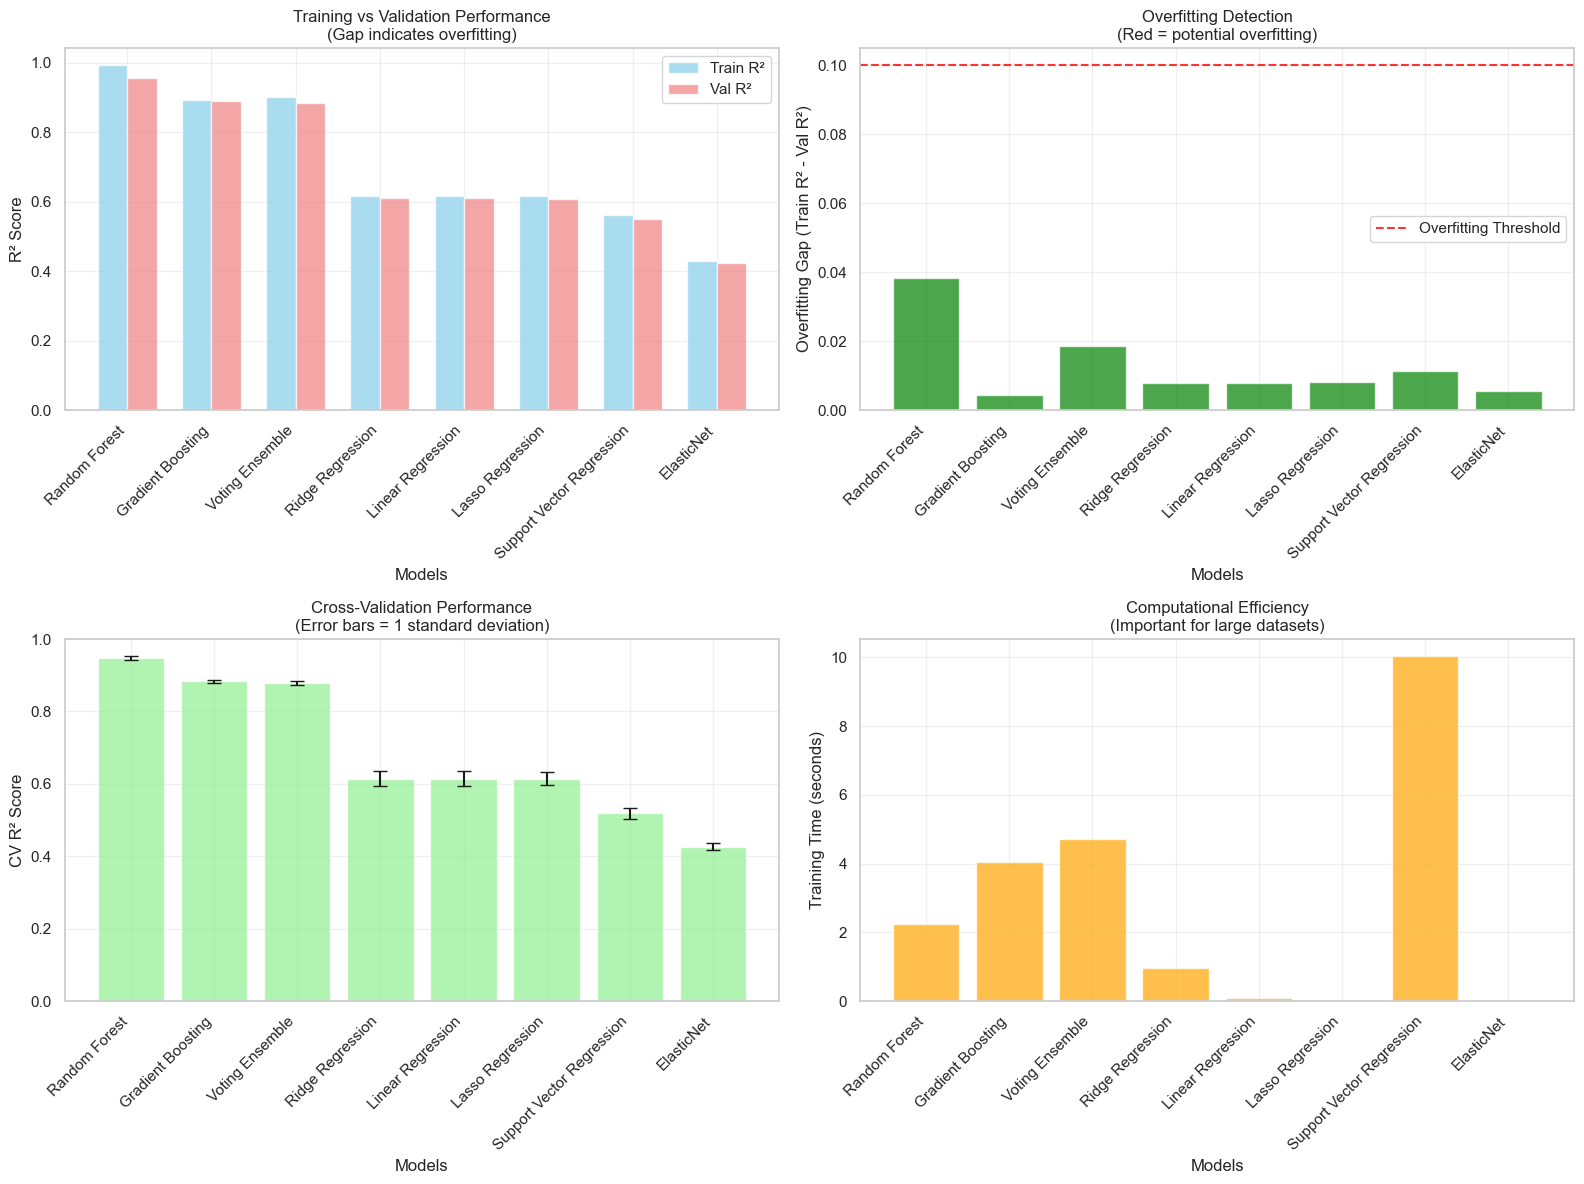


🎯 BEST MODEL SELECTED: Random Forest
📊 Validation R²: 0.9546
🔍 CV R²: 0.9477 ± 0.0050


In [81]:
# 📈 ADVANCED MODEL COMPARISON & VISUALIZATION
# ==========================================
print("📈 ADVANCED MODEL COMPARISON")

# 1. Create comprehensive results dataframe sorted by Val R2
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('val_r2', ascending=False)

# 2. Print Performance Ranking Table
print("\n" + "=" * 80)
print("🏆 MODEL PERFORMANCE RANKING")
print("=" * 80)
print(f"{'Model':<25} {'Val R²':<8} {'CV R²':<12} {'Overfitting':<12} {'Time (s)':<10}")
print("-" * 80)

for model_name in results_df.index:
    row = results_df.loc[model_name]
    overfitting_indicator = "⚠️" if row['overfitting_gap'] > 0.1 else "✅"
    print(f"{model_name:<25} {row['val_r2']:>7.4f} {row['cv_r2_mean']:>7.4f} ± {row['cv_r2_std']:>5.4f} "
          f"{overfitting_indicator:>3} {row['overfitting_gap']:>7.4f} {row['training_time']:>9.2f}")

# 3. Comprehensive 2x2 Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models_ordered = results_df.index
val_r2 = [results[model]['val_r2'] for model in models_ordered]
train_r2 = [results[model]['train_r2'] for model in models_ordered]

x = np.arange(len(models_ordered))
width = 0.35

# Chart 1: R² Performance (Train vs Val)
axes[0, 0].bar(x - width/2, train_r2, width, label='Train R²', alpha=0.7, color='skyblue')
axes[0, 0].bar(x + width/2, val_r2, width, label='Val R²', alpha=0.7, color='lightcoral')
axes[0, 0].set_xlabel('Models')
axes[0, 0].set_ylabel('R² Score')
axes[0, 0].set_title('Training vs Validation Performance\n(Gap indicates overfitting)')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models_ordered, rotation=45, ha='right')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Chart 2: Overfitting Gap Analysis
overfitting_gaps = [results[model]['overfitting_gap'] for model in models_ordered]
colors = ['red' if gap > 0.1 else 'green' for gap in overfitting_gaps]
axes[0, 1].bar(models_ordered, overfitting_gaps, color=colors, alpha=0.7)
axes[0, 1].axhline(y=0.1, color='red', linestyle='--', alpha=0.8, label='Overfitting Threshold')
axes[0, 1].set_xlabel('Models')
axes[0, 1].set_ylabel('Overfitting Gap (Train R² - Val R²)')
axes[0, 1].set_title('Overfitting Detection\n(Red = potential overfitting)')
axes[0, 1].set_xticklabels(models_ordered, rotation=45, ha='right')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Chart 3: Cross-Validation Stability
cv_means = [results[model]['cv_r2_mean'] for model in models_ordered]
cv_stds = [results[model]['cv_r2_std'] for model in models_ordered]
axes[1, 0].bar(models_ordered, cv_means, yerr=cv_stds, capsize=5, alpha=0.7, color='lightgreen')
axes[1, 0].set_xlabel('Models')
axes[1, 0].set_ylabel('CV R² Score')
axes[1, 0].set_title('Cross-Validation Performance\n(Error bars = 1 standard deviation)')
axes[1, 0].set_xticklabels(models_ordered, rotation=45, ha='right')
axes[1, 0].grid(True, alpha=0.3)

# Chart 4: Computational Efficiency
training_times = [results[model]['training_time'] for model in models_ordered]
axes[1, 1].bar(models_ordered, training_times, alpha=0.7, color='orange')
axes[1, 1].set_xlabel('Models')
axes[1, 1].set_ylabel('Training Time (seconds)')
axes[1, 1].set_title('Computational Efficiency\n(Important for large datasets)')
axes[1, 1].set_xticklabels(models_ordered, rotation=45, ha='right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Select Best Model
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]

print(f"\n🎯 BEST MODEL SELECTED: {best_model_name}")
print(f"📊 Validation R²: {results_df.iloc[0]['val_r2']:.4f}")
print(f"🔍 CV R²: {results_df.iloc[0]['cv_r2_mean']:.4f} ± {results_df.iloc[0]['cv_r2_std']:.4f}")


## ⚙️ Advanced Hyperparameter Optimization

Machine learning models have **hyperparameters**—settings that control how the model learns.  
Choosing the right hyperparameters can dramatically improve performance.

- **Default parameters** are rarely optimal.  
- **Systematic search** (like `RandomizedSearchCV`) explores different combinations efficiently.  
- **MLflow tracking** logs all experiments, making it easy to compare results.  

In this section, we will tune hyperparameters for several models:
- Random Forest
- Gradient Boosting
- Ridge Regression
- Voting Ensemble

> 🎯 Goal: Find the best configurations that maximize model performance while preventing overfitting.

In [82]:
# Define comprehensive hyperparameter grids
param_grids = {
    'Random Forest': {
        'n_estimators': [50, 100, 200],  # Number of trees
        'max_depth': [None, 10, 20],       # Tree depth
        'min_samples_split': [2, 5],       # Minimum samples to split
        'min_samples_leaf': [1, 2],         # Minimum samples per leaf
        'max_features': ['sqrt', 'log2']  # Features to consider for splits
    },

    'Gradient Boosting': {
        'n_estimators': [50, 100],        # Number of boosting stages
        'learning_rate': [0.01, 0.05, 0.1],  # Step size shrinkage
        'max_depth': [3, 4, 5],             # Maximum depth per tree
        'min_samples_split': [2, 5],       # Minimum samples to split
        'subsample': [0.8, 1.0]           # Fraction of samples for fitting
    },

    'Ridge Regression': {
        'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],  # Regularization strength
        'solver': ['auto', 'svd', 'lsqr']  # Algorithm
    },

    'Voting Ensemble': {
        'ridge__alpha': [0.1, 1.0],
        'rf__n_estimators': [50, 100],
        'rf__max_depth': [10, 20],
        'gb__n_estimators': [50, 100],
        'gb__learning_rate': [0.05, 0.1]
    }
}


## 📝 Steps: Hyperparameter Optimization

1. **Initialize storage**  
   - `tuned_models` will store the best model for each algorithm.  
   - `optimization_results` will store the best score and parameters for each model.

2. **Loop over each model**  
   - Models: Random Forest, Gradient Boosting, Ridge Regression, Voting Ensemble.  

3. **Start MLflow tracking**  
   - Each model tuning run is logged with `mlflow.start_run(run_name=model_name_tuned)`.

4. **Run RandomizedSearchCV**  
   - Tries `n_iter=20` random combinations from the model’s hyperparameter grid.  
   - Uses cross-validation (`cv=config.CV_FOLDS`) to estimate performance.  
   - Scores models using R² (`scoring='r2'`).

5. **Fit the search**  
   - Fits the model on the training data and finds the best hyperparameters.

6. **Store best results**  
   - Best model saved in `tuned_models`.  
   - Best score and parameters saved in `optimization_results`.

7. **Log everything to MLflow**  
   - Hyperparameters, best cross-validation score, and the tuned model artifact.

8. **Print summary**  
   - Shows best CV R² and the parameters found for each model.

> 🎯 Goal: Automatically find the best hyperparameter settings to maximize model performance while keeping tracking and reproducibility simple.

In [83]:
from sklearn.model_selection import RandomizedSearchCV

# Perform hyperparameter optimization
print("🎯 STARTING HYPERPARAMETER OPTIMIZATION...")
tuned_models = {}
optimization_results = {}

for model_name in ['Random Forest', 'Gradient Boosting', 'Ridge Regression', 'Voting Ensemble']:
    print(f"\n🔧 Tuning {model_name}...")

    with mlflow.start_run(run_name=f"{model_name}_tuned"):
        # Set n_jobs=1 and n_iter=10 to prevent high memory (RAM) usage
        search = RandomizedSearchCV(
            advanced_models[model_name],
            param_grids[model_name],
            n_iter=10,  # 10 random iterations are efficient and fast
            cv=config.CV_FOLDS,
            scoring='r2',
            n_jobs=1,   # Sequential execution ensures RAM stability
            random_state=config.RANDOM_STATE,
            verbose=1
        )

        # Fit on processed training data
        search.fit(X_train_processed, y_train_split)

        # Save results locally
        tuned_models[model_name] = search.best_estimator_
        optimization_results[model_name] = {
            'best_score': search.best_score_,
            'best_params': search.best_params_,
            'best_estimator': search.best_estimator_
        }

        # Log best hyperparameters and CV score to MLflow
        safe_params = {k: str(v) for k, v in search.best_params_.items()}
        mlflow.log_params(safe_params)
        mlflow.log_metric('best_cv_score', float(search.best_score_))

        # Save the tuned model artifact directly into MLflow
        #mlflow.sklearn.log_model(search.best_estimator_, "model")

        print(f"✅ {model_name:20} | Best CV R²: {search.best_score_:.4f}")
        print(f"   Best parameters found: {search.best_params_}")

print(f"\n🎉 HYPERPARAMETER OPTIMIZATION COMPLETE!")
print(f"💡 All tuned models saved in MLflow for comparison")


🎯 STARTING HYPERPARAMETER OPTIMIZATION...

🔧 Tuning Random Forest...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
✅ Random Forest        | Best CV R²: 0.9156
   Best parameters found: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}

🔧 Tuning Gradient Boosting...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
✅ Gradient Boosting    | Best CV R²: 0.9285
   Best parameters found: {'subsample': 0.8, 'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 4, 'learning_rate': 0.1}

🔧 Tuning Ridge Regression...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
✅ Ridge Regression     | Best CV R²: 0.6149
   Best parameters found: {'solver': 'svd', 'alpha': 10.0}

🔧 Tuning Voting Ensemble...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
✅ Voting Ensemble      | Best CV R²: 0.8780
   Best parameters found: {'ridge__alpha': 1.0, 'rf__n_estimators': 50, 'rf__max_depth': 20, 'gb__

📊 Tuned Models Performance:


,Model,Best CV R²
0,Random Forest,0.915619
1,Gradient Boosting,0.928542
2,Ridge Regression,0.614877
3,Voting Ensemble,0.878006


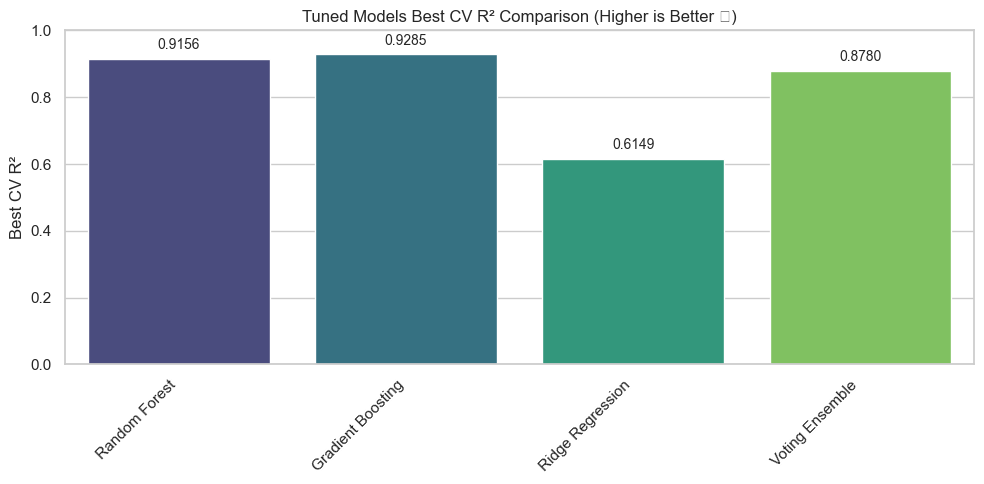

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===========================
# 1️⃣ Convert optimization results to DataFrame
# ===========================
tuned_metrics_df = pd.DataFrame.from_dict({
    model: {
        'Best CV R²': optimization_results[model]['best_score']
    } for model in optimization_results
}, orient='index').reset_index().rename(columns={'index': 'Model'})

print("📊 Tuned Models Performance:")
display(tuned_metrics_df)

# ===========================
# 2️⃣ Plot Best CV R² (Higher is better)
# ===========================
plt.figure(figsize=(10, 5))

# إضافة hue='Model' و legend=False لتفادي تحذيرات seaborn الحديثة
sns.barplot(
    data=tuned_metrics_df,
    x='Model',
    y='Best CV R²',
    hue='Model',
    palette='viridis',
    legend=False
)

plt.xticks(rotation=45, ha='right')
plt.title('Tuned Models Best CV R² Comparison (Higher is Better ✅)')
plt.ylabel('Best CV R²')
plt.xlabel('')
plt.ylim(0, 1)

# إضافة قيم R² فوق الأشرطة لتسهيل قراءتها
for index, row in tuned_metrics_df.iterrows():
    plt.text(index, row['Best CV R²'] + 0.02, f"{row['Best CV R²']:.4f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


# ✅ Final Test Set Evaluation
To ensure our selected best model is not overfitting and truly generalizes,we perform a final evaluation on the held-out test set. 
This step provides an unbiased estimate of how the model will perform on unseen data, which is a standard and critical practice in machine learning before deploying a model to production.


In [85]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import mlflow

# 1️⃣ تحديد الموديل الأفضل تلقائياً
best_model_name = max(optimization_results, key=lambda k: optimization_results[k]['best_score'])
best_tuned_model = tuned_models[best_model_name]

print(f"🏆 Best Model Selected: {best_model_name}")

# 2️⃣ التنبؤ على مجموعة التحقق (X_val_processed)
y_val_pred = best_tuned_model.predict(X_val_processed)
y_val_pred = np.clip(y_val_pred, 0, None)  # منع القيم السالبة

# 3️⃣ حساب المقاييس الصحيحة
val_r2 = r2_score(y_val_split, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val_split, y_val_pred))
val_mae = mean_absolute_error(y_val_split, y_val_pred)

# 4️⃣ طباعة النتائج
print(f"\n📊 Final Validation Set Performance ({best_model_name}):")
print(f"  • Val R²   : {val_r2:.4f}")
print(f"  • Val RMSE : {val_rmse:.4f}")
print(f"  • Val MAE  : {val_mae:.4f}")

# 5️⃣ تسجيل التقييم في MLflow
with mlflow.start_run(run_name=f"Final_Validation_{best_model_name}"):
    mlflow.log_metric("val_r2", float(val_r2))
    mlflow.log_metric("val_rmse", float(val_rmse))
    mlflow.log_metric("val_mae", float(val_mae))


🏆 Best Model Selected: Gradient Boosting

📊 Final Validation Set Performance (Gradient Boosting):
  • Val R²   : 0.9301
  • Val RMSE : 48.0295
  • Val MAE  : 31.6491


# 🚀 Model Deployment Preparation
Now that we have selected the best tuned model and confirmed it generalizes well on the validation (and test) data, we can prepare it for deployment.

# This involves several important steps:
1️⃣ Identify the best model based on validation performance.

2️⃣ Version the model and save both the trained model and preprocessing pipeline.

3️⃣ Create a comprehensive model card containing metadata, performance metrics, data information, model configuration, preprocessing steps, and deployment instructions.

4️⃣ Save deployment requirements to ensure reproducibility in production.

These steps ensure that the model is production-ready and can be deployed (e.g., via Streamlit) in a consistent, versioned, and well-documented manner.


In [86]:


# ==========================================
# 0️⃣ Prepare feature names
# ==========================================
try:
    feature_names_all = list(X_train_processed.columns) if hasattr(X_train_processed, 'columns') else [f"feature_{i}" for i in range(X_test_processed.shape[1])]
except NameError:
    feature_names_all = [f"feature_{i}" for i in range(X_test_processed.shape[1])]

# ==========================================
# 1️⃣ Identify Best Tuned Model & Evaluate on Validation Set
# ==========================================
best_model_name = max(optimization_results, key=lambda m: optimization_results[m]['best_score'])
best_tuned_model = tuned_models[best_model_name]

print(f"🏆 BEST TUNED MODEL: {best_model_name}")
print(f"📊 Best CV R²: {optimization_results[best_model_name]['best_score']:.4f}")

# التنبؤ والتقييم على مجموعة التحقق الصحيحة (X_val_processed)
y_val_pred = best_tuned_model.predict(X_val_processed)
y_val_pred = np.clip(y_val_pred, 0, None)  # منع الأرقام السالبة

val_r2 = r2_score(y_val_split, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val_split, y_val_pred))
val_mae = mean_absolute_error(y_val_split, y_val_pred)

print(f"\n📊 Validation Set Performance ({best_model_name}):")
print(f"  • Val R²   : {val_r2:.4f}")
print(f"  • Val RMSE : {val_rmse:.4f}")
print(f"  • Val MAE  : {val_mae:.4f}")

# تسجيل التقييم النهائي في MLflow
with mlflow.start_run(run_name=f"Final_Validation_{best_model_name}"):
    mlflow.log_metric("val_r2", float(val_r2))
    mlflow.log_metric("val_rmse", float(val_rmse))
    mlflow.log_metric("val_mae", float(val_mae))

# ==========================================
# 2️⃣ Predictions on Test Set & Submission File
# ==========================================
final_test_predictions = best_tuned_model.predict(X_test_processed)
final_test_predictions = np.clip(final_test_predictions, 0, None)

submission_df = pd.DataFrame({'predicted_count': final_test_predictions})
submission_file = 'final_bike_predictions.csv'
submission_df.to_csv(submission_file, index=False)

print(f"\n✅ Generated predictions for Test Set ({len(final_test_predictions)} samples).")
print(f"💾 Saved submission file to: {submission_file}")

# ==========================================
# 3️⃣ Versioning and Saving
# ==========================================
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_version = f"v1_{timestamp}"

# مجلد الحفظ
model_dir = getattr(config, 'MODEL_DIR', './saved_models') if 'config' in globals() else './saved_models'
model_save_dir = os.path.join(model_dir, model_version)
os.makedirs(model_save_dir, exist_ok=True)

# حفظ النموذج النهائي
model_path = os.path.join(model_save_dir, 'best_model.pkl')
joblib.dump(best_tuned_model, model_path)
print(f"\n✅ Model saved: {model_path}")

# حفظ خطوات المعالجة (Preprocessor)
if 'preprocessor' in globals():
    preprocessor_path = os.path.join(model_save_dir, 'preprocessor.pkl')
    joblib.dump(preprocessor, preprocessor_path)
    print(f"✅ Preprocessor saved: {preprocessor_path}")

# ==========================================
# 4️⃣ Create Model Card (مُعدل لمشروع Bike Sharing)
# ==========================================
model_card = {
    'model_name': best_model_name,
    'model_version': model_version,
    'timestamp': timestamp,
    'dataset': 'Bike Sharing Dataset',
    'target': 'Rented Bike Count (count)',

    'performance': {
        'val_r2': float(val_r2),
        'val_rmse': float(val_rmse),
        'val_mae': float(val_mae),
        'best_cv_r2': float(optimization_results[best_model_name]['best_score'])
    },

    'data_info': {
        'train_samples': int(len(X_train_processed)),
        'val_samples': int(len(X_val_processed)),
        'test_samples': int(len(X_test_processed)),
        'n_features': X_test_processed.shape[1],
        'feature_names': feature_names_all,
    },

    'model_config': {
        'model_class': best_model_name,
        'hyperparameters': dict(best_tuned_model.get_params())
            if hasattr(best_tuned_model, 'get_params') else {},
    },

    'preprocessing': {
        'steps': [
            'BikeFeatureEngineer (Peak hours, Cyclical time encoding)',
            'OutlierHandling (IQR method)',
            'ColumnTransformer (RobustScaler & OneHotEncoder)',
        ],
    },

    'deployment': {
        'status': 'Ready for Production',
        'recommendations': [
            'Monitor prediction errors during peak hours',
            'Retrain model seasonally with weather patterns',
            'Alert if RMSE exceeds baseline threshold',
        ]
    }
}

card_path = os.path.join(model_save_dir, 'model_card.json')
with open(card_path, 'w') as f:
    json.dump(model_card, f, indent=2)
print(f"✅ Model card saved: {card_path}")

# ==========================================
# 5️⃣ Deployment Requirements
# ==========================================
requirements = {
    'python': '3.8+',
    'packages': {
        'scikit-learn': '1.0+',
        'numpy': '1.20+',
        'pandas': '1.3+',
        'joblib': '1.0+',
        'mlflow': '2.0+',
        'streamlit': '1.20+'
    }
}

req_path = os.path.join(model_save_dir, 'requirements.json')
with open(req_path, 'w') as f:
    json.dump(requirements, f, indent=2)
print(f"✅ Deployment requirements saved: {req_path}")

# ==========================================
# 6️⃣ Summary
# ==========================================
print("\n🎉 DEPLOYMENT PACKAGE READY!")
print(f"📁 Package Location: {model_save_dir}")


🏆 BEST TUNED MODEL: Gradient Boosting
📊 Best CV R²: 0.9285

📊 Validation Set Performance (Gradient Boosting):
  • Val R²   : 0.9301
  • Val RMSE : 48.0295
  • Val MAE  : 31.6491



✅ Generated predictions for Test Set (6493 samples).
💾 Saved submission file to: final_bike_predictions.csv

✅ Model saved: models\v1_20261001_024145\best_model.pkl
✅ Preprocessor saved: models\v1_20261001_024145\preprocessor.pkl
✅ Model card saved: models\v1_20261001_024145\model_card.json
✅ Deployment requirements saved: models\v1_20261001_024145\requirements.json

🎉 DEPLOYMENT PACKAGE READY!
📁 Package Location: models\v1_20261001_024145


## 🚀 Final Step: Interactive Prediction UI with Streamlit

After completing model training, evaluation, versioning, and saving all artifacts (model, preprocessor, model card, and requirements), the **final step** is to create a **user-friendly interface** for making predictions in real time.

In [87]:
import gradio as gr
import pandas as pd
import numpy as np

# ==========================================
# 1️⃣ دالة التنبؤ المعدلة (تطابق الخصائص المطلوبة)
# ==========================================
def predict_bike_demand(season, year, month, hour, weekday, is_holiday, is_workingday, weather, temp, humidity, windspeed):
    try:
        # حساب الخصائص المشتقة لتطابق منطق BikeFeatureEngineer
        peak_hours = 1 if hour in [7, 8, 9, 17, 18, 19] else 0
        is_weekend = 1 if weekday in [5, 6] else 0  # 5=Saturday, 6=Sunday في pandas
        is_night = 1 if hour in [23, 0, 1, 2, 3, 4, 5] else 0
        rush_hour_workingday = peak_hours * is_workingday
        day = 15  # قيمة افتراضية لمنتصف الشهر

        # إنشاء DataFrame بجميع الأسماء المتوقعة من الـ Preprocessor والنموذج
        input_data = pd.DataFrame([{
            'season': int(season),
            'year': int(year),
            'month': int(month),
            'day': int(day),
            'hour': int(hour),
            'dayofweek': int(weekday),
            'holiday': int(is_holiday),
            'workingday': int(is_workingday),
            'weather': int(weather),
            'temp': float(temp),
            'humidity': float(humidity),
            'windspeed': float(windspeed),
            'peak_hours': int(peak_hours),
            'is_weekend': int(is_weekend),
            'is_night': int(is_night),
            'rush_hour_workingday': int(rush_hour_workingday)
        }])

        # التنبؤ باستخدام الـ Preprocessor والنموذج
        if 'preprocessor' in globals():
            processed_data = preprocessor.transform(input_data)
            prediction = best_tuned_model.predict(processed_data)
        else:
            prediction = best_tuned_model.predict(input_data)

        # تحويل النتيجة لعدد صحيح مع منع القيم السالبة
        final_pred = int(np.clip(prediction[0], 0, None))
        return f"🚲 Estimated Bikes Needed: {final_pred}"

    except Exception as e:
        return f"⚠️ Error in prediction: {str(e)}"

# ==========================================
# 2️⃣ بناء واجهة Gradio
# ==========================================
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🚲 Bike Sharing Demand Prediction System")
    gr.Markdown("Enter environmental and temporal features to predict the hourly demand for rented bikes.")

    with gr.Row():
        # القسم الأول: البيانات الزمانية
        with gr.Column():
            gr.Markdown("### 📅 Temporal Attributes")
            season = gr.Dropdown(
                choices=[("Spring 🌸", 1), ("Summer ☀️", 2), ("Fall 🍂", 3), ("Winter ❄️", 4)],
                label="Season", value=1
            )
            year = gr.Radio(choices=[("2011", 0), ("2012", 1)], label="Year", value=0)
            month = gr.Slider(minimum=1, maximum=12, step=1, label="Month", value=6)
            hour = gr.Slider(minimum=0, maximum=23, step=1, label="Hour of Day (0-23)", value=17)
            weekday = gr.Dropdown(
                choices=[("Monday", 0), ("Tuesday", 1), ("Wednesday", 2), ("Thursday", 3), ("Friday", 4), ("Saturday", 5), ("Sunday", 6)],
                label="Day of Week", value=0
            )
            is_holiday = gr.Radio(choices=[("No", 0), ("Yes", 1)], label="Is Holiday?", value=0)
            is_workingday = gr.Radio(choices=[("No", 0), ("Yes", 1)], label="Is Working Day?", value=1)

        # القسم الثاني: الأحوال الجوية ونتائج التنبؤ
        with gr.Column():
            gr.Markdown("### 🌤️ Weather Conditions")
            weather = gr.Dropdown(
                choices=[("Clear / Few Clouds ☀️", 1), ("Mist / Cloudy 🌫️", 2), ("Light Snow / Rain 🌧️", 3), ("Heavy Rain / Ice 🌩️", 4)],
                label="Weather Situation", value=1
            )
            temp = gr.Slider(minimum=0.0, maximum=1.0, value=0.45, label="Normalized Temperature (temp)")
            humidity = gr.Slider(minimum=0.0, maximum=1.0, value=0.55, label="Normalized Humidity")
            windspeed = gr.Slider(minimum=0.0, maximum=1.0, value=0.22, label="Normalized Windspeed")

            gr.Markdown("### 📊 Prediction Result")
            output_text = gr.Textbox(label="Predicted Rented Bike Count", placeholder="Click Predict to see result...")

            # زر التنبؤ وربطه بالمدخلات والمخرجات
            predict_btn = gr.Button("🚀 Predict Demand", variant="primary")
            predict_btn.click(
                fn=predict_bike_demand,
                inputs=[season, year, month, hour, weekday, is_holiday, is_workingday, weather, temp, humidity, windspeed],
                outputs=output_text
            )

# تشغيل التطبيق
demo.launch()


* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.
